In [21]:
import numpy as np

def make_spirals(n_samples: int=100, noise: float=0.0, turns: int=1) -> tuple[np.ndarray, np.ndarray]:
  """
  Generate a spirals dataset.

  Parameters
  ----------
  n_samples : int, optional
    The number of samples to generate, by default 100
  noise : float, optional
    The standard deviation of the Gaussian noise added to the data, by default 0.0

  Returns
  -------
  tuple[np.ndarray, np.ndarray]
    A tuple containing the generated data points and their corresponding labels.
  """

  samples_per_class = n_samples // 2

  n = np.sqrt(np.random.rand(n_samples)) * 2 * turns * np.pi
  x = n * np.sin(n) + np.random.randn(n_samples) * noise
  y = n * np.cos(n) + np.random.randn(n_samples) * noise
  
  X = np.array(list(zip(x, y)))
  y = np.array([0] * samples_per_class + [1] * samples_per_class)
  
  # Rotate one class 180 degrees
  X[samples_per_class:] = -X[samples_per_class:]
  
  return X, y

In [22]:
def make_grid(X, step=1):
  """
  Create a grid of points for contour plotting
  
  Parameters
  ----------
  X : array-like of shape (n_samples, n_features)
    Input data
  step : float, default=1
    Step size for grid points
    
  Returns
  -------
  xx : ndarray of shape (n_points, 2)
    Grid points
  """

  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                       np.arange(y_min, y_max, step))
  
  return np.c_[xx.ravel(), yy.ravel()]

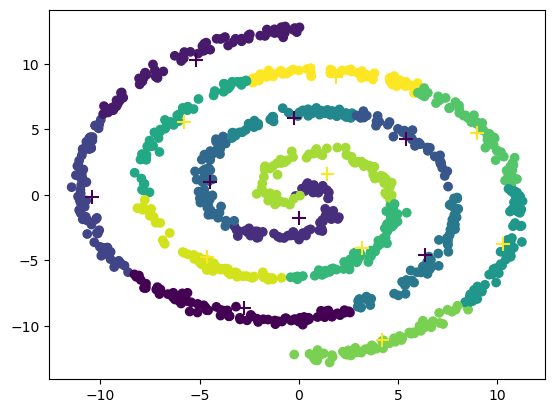

In [23]:
X, y = make_spirals(1000, 0.2, 2)
G = make_grid(X, 0.1)

X0, X1 = X[y == 0], X[y == 1]

from sklearn.cluster import KMeans

n_clusters = 8

km0 = KMeans(n_clusters=n_clusters).fit(X0)
km1 = KMeans(n_clusters=n_clusters).fit(X1)

cxbar = np.vstack([km0.cluster_centers_, km1.cluster_centers_])
cy = np.array([0]*n_clusters + [1]*n_clusters)

s = np.zeros_like(y)

s[y == 0] = km0.labels_ + n_clusters * 0
s[y == 1] = km1.labels_ + n_clusters * 1

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=s)
plt.scatter(cxbar[:, 0], cxbar[:, 1], marker='+', c=cy, s=100)
plt.savefig('kmeans.png')
plt.show()
plt.close()

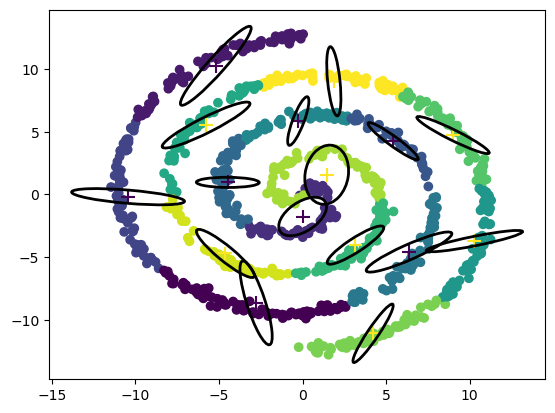

In [24]:
covs = {}

for sid in np.unique(s):
  csamples = X[s == sid]
  covs[sid] = np.cov(csamples, rowvar=False)

plt.figure()
# Visualize with covariance ellipses
scatter = plt.scatter(X[:, 0], X[:, 1], c=s)

# Plot cluster centers
plt.scatter(cxbar[:, 0], cxbar[:, 1], c=cy, marker='+', s=100)

# Plot covariance ellipses
for cluster_id, cov_matrix in covs.items():
  # Calculate eigenvalues and eigenvectors
  eigvals, eigvecs = np.linalg.eigh(cov_matrix)
  
  # Create ellipse parameters
  angle = np.degrees(np.arctan2(*eigvecs[0]))
  width, height = 2 * np.sqrt(eigvals)
  
  # Create and plot ellipse
  ellipse = plt.matplotlib.patches.Ellipse(
    cxbar[cluster_id], width, height, angle=angle,
    edgecolor='black', facecolor='none', linewidth=2
  )
  plt.gca().add_patch(ellipse)

plt.savefig('kmeans_ellipses.png')
plt.show()
plt.close()


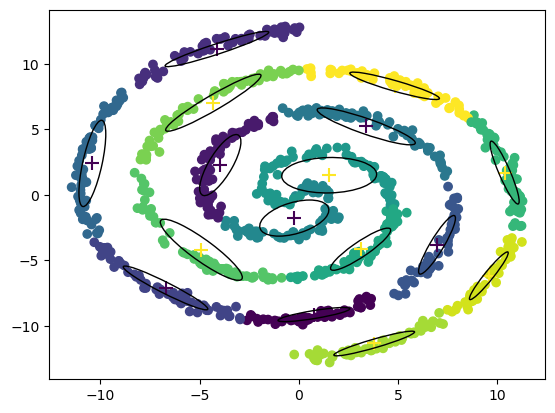

In [31]:
from sklearn.mixture import GaussianMixture

gmm0 = GaussianMixture(n_components=n_clusters).fit(X0)
gmm1 = GaussianMixture(n_components=n_clusters).fit(X1)

means = np.vstack([gmm0.means_, gmm1.means_])
covariances = np.vstack([gmm0.covariances_, gmm1.covariances_])
cy = np.array([0]*n_clusters + [1]*n_clusters)

s = np.zeros_like(y)
s[y == 0] = gmm0.predict(X0) + n_clusters * 0
s[y == 1] = gmm1.predict(X1) + n_clusters * 1

plt.figure()
scatter = plt.scatter(X[:, 0], X[:, 1], c=s)
plt.scatter(means[:, 0], means[:, 1], c=cy, marker='+', s=100)

# Plot covariance ellipses
for cluster_id, (mean, cov) in enumerate(zip(means, covariances)):
  # Calculate eigenvalues and eigenvectors
  eigvals, eigvecs = np.linalg.eigh(cov)
  
  # Calculate ellipse parameters
  angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
  width, height = 2 * np.sqrt(eigvals)
  
  # Create and plot ellipse
  ellipse = plt.matplotlib.patches.Ellipse(
    mean, width, height, angle=angle,
    edgecolor='black', facecolor='none'
  )
  plt.gca().add_patch(ellipse)

plt.savefig('gmm_ellipses.png')
plt.show()
plt.close()

In [26]:
from sklearn.base import BaseEstimator, ClusterMixin

class BayesGMM(BaseEstimator, ClusterMixin):
  def __init__(self, n_components=1):
    self.n_components = n_components
  
  def fit(self, X, y):
    self.targets = np.unique(y)

    self.models = {}
    self.priors = {}

    for target in self.targets:
      self.models[target] = GaussianMixture(n_components=self.n_components)
      self.models[target].fit(X[y == target])
      self.priors[target] = np.sum(y == target) / len(y)

    return self
  
  def predict(self, X):
    probs = np.zeros((X.shape[0], len(self.targets)))

    for target in self.targets:
      probs[:, target] = self.models[target].score_samples(X) + np.log(self.priors[target])

    return probs.argmax(axis=1)

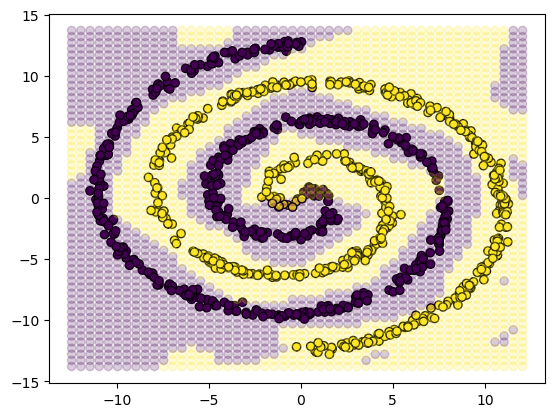

In [27]:
G = make_grid(X, 0.5)

bgmm = BayesGMM(n_components=n_clusters).fit(X, y)

Z = bgmm.predict(G)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.scatter(G[:, 0], G[:, 1], c=Z, alpha=0.2)
plt.savefig('gmm_dec_bound.png')
plt.show()
plt.close()

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
  'n_components': range(1, 11),
}

grid = GridSearchCV(
  BayesGMM(),
  param_grid,
  scoring='accuracy',
  n_jobs=-1,
)

grid.fit(X, y)

best_n_components = grid.best_params_['n_components']
print(f"Best number of components: {best_n_components}")

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

kf = KFold(n_splits=10, shuffle=True)

scores = cross_val_score(
  BayesGMM(n_components=best_n_components),
  X, y,
  cv=kf,
  scoring='accuracy',
  n_jobs=-1
)

mean_score = scores.mean()
std_score = scores.std()

import csv

with open('scores.csv', mode='w', newline='') as file:
  writer = csv.writer(file)
  writer.writerow(['Fold', 'Score'])
  for fold, score in enumerate(scores, start=1):
    writer.writerow([fold, score])
  writer.writerow(['Mean Score', f'{mean_score:.2f}'])

Best number of components: 10
